# Hospital Readmission Prediction - EDA Notebook

**Course project topic:** Hospital Readmission Prediction Classification  
**Dataset:** UCI Diabetes 130-US Hospitals dataset (`archive/diabetic_data.csv`)  
**Goal:** Predict whether a patient will be readmitted within 30 days of discharge.

This notebook is an EDA-first version based on the direction of the older readmission notebook in this folder. It does not train final models yet. The purpose is to understand the data, define the target, identify cleaning decisions, and prepare a strong foundation for preprocessing and model comparison later.

## Project Fit

The course project asks for data collection, EDA, preprocessing, model training, evaluation, a written report, and reproducible code. This notebook covers the EDA portion and records modeling decisions that should be used in the next notebook/script.

Why this dataset fits the suggested topic:

- It is a ready-to-use public dataset with more than 500 samples and more than 5 meaningful features.
- It contains a supervised classification target: `readmitted` with values `<30`, `>30`, and `NO`.
- It addresses a real healthcare need: helping hospitals and insurers identify patients at high risk of avoidable readmission.

In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
COLOR_MAIN = "#2F6B9A"
COLOR_ACCENT = "#D95F02"
COLOR_GOOD = "#1B9E77"
COLOR_WARN = "#E6AB02"
COLOR_MUTED = "#666666"
PALETTE = [COLOR_MAIN, COLOR_ACCENT, COLOR_GOOD, COLOR_WARN, "#7570B3", "#E7298A", "#66A61E"]

%matplotlib inline

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "archive" / "diabetic_data.csv"
COURSE_DESCRIPTION_PATH = PROJECT_ROOT / "project_description.pdf"
OLD_NOTEBOOK_PATH = PROJECT_ROOT / "prediction-on-hospital-readmission.ipynb"

print("Project root:", PROJECT_ROOT)
print("Data file exists:", DATA_PATH.exists(), "->", DATA_PATH)
print("Old notebook exists:", OLD_NOTEBOOK_PATH.exists())
print("Course description exists:", COURSE_DESCRIPTION_PATH.exists())

Project root: /Users/mohamed.farrag/Downloads/MLPROJECT
Data file exists: True -> /Users/mohamed.farrag/Downloads/MLPROJECT/archive/diabetic_data.csv
Old notebook exists: True
Course description exists: True


## Load Data Carefully

Important detail: in this dataset, the string `None` means a lab test was not performed for `A1Cresult` and `max_glu_serum`. It is a meaningful category, not missing data. Missing values are encoded as `?`, so the loader below only converts `?` to missing.

In [3]:
raw = pd.read_csv(
    DATA_PATH,
    na_values=["?"],
    keep_default_na=False,
    low_memory=False,
)

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
display(raw.head())

Raw shape: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
def count_percent(series, sort=True):
    counts = series.value_counts(dropna=False)
    if not sort:
        counts = counts.reindex(series.dropna().unique())
    out = pd.DataFrame({"count": counts, "percent": counts / len(series) * 100})
    return out


def category_summary(data, column, target="readmitted_30", min_count=0, order=None):
    temp = pd.DataFrame({
        "category": data[column].astype("object").where(data[column].notna(), "Missing").astype(str),
        target: data[target]
    })
    out = temp.groupby("category", observed=False)[target].agg(count="count", readmit_rate="mean").reset_index()
    out["readmit_rate_pct"] = out["readmit_rate"] * 100
    out = out[out["count"] >= min_count].copy()
    if order is not None:
        out["category"] = pd.Categorical(out["category"], categories=[str(x) for x in order], ordered=True)
        out = out.sort_values("category")
    else:
        out = out.sort_values("count", ascending=False)
    return out


def plot_countplot(data, column, order=None, top_n=None, title=None, ax=None, rotation=35):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    temp = data[column].astype("object").where(data[column].notna(), "Missing").astype(str)
    if order is None:
        order = temp.value_counts().head(top_n).index if top_n else temp.value_counts().index
    sns.countplot(x=temp, order=[str(x) for x in order], color=COLOR_MAIN, ax=ax)
    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=rotation)
    return ax


def plot_target_rate(data, column, order=None, top_n=None, min_count=0, title=None, ax=None, rotation=35):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    table = category_summary(data, column, min_count=min_count, order=order)
    if order is None and top_n:
        table = table.head(top_n)
    sns.barplot(data=table, x="category", y="readmit_rate_pct", color=COLOR_ACCENT, ax=ax)
    ax.axhline(data["readmitted_30"].mean() * 100, ls="--", lw=1.2, color=COLOR_MUTED, label="Overall rate")
    ax.set_title(title or f"30-day readmission rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Readmitted within 30 days (%)")
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(loc="best")
    return ax


def two_panel_category(data, column, order=None, top_n=None, min_count=0, title=None, rotation=35):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    plot_countplot(data, column, order=order, top_n=top_n, title=f"{column}: count", ax=axes[0], rotation=rotation)
    plot_target_rate(data, column, order=order, top_n=top_n, min_count=min_count, title=f"{column}: 30-day readmission rate", ax=axes[1], rotation=rotation)
    fig.suptitle(title or column, y=1.04, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def display_section(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

## Data Dictionary

The table below keeps the main variables close to the EDA. The IDs for admission type, discharge disposition, and admission source are numeric codes in the original UCI release; we will group them into interpretable categories later in the notebook.

In [5]:
data_dictionary = pd.DataFrame([
    ("encounter_id", "Unique encounter/admission identifier"),
    ("patient_nbr", "Unique patient identifier; patients can have multiple encounters"),
    ("race", "Patient race"),
    ("gender", "Patient gender"),
    ("age", "Age bucket in 10-year intervals"),
    ("weight", "Weight bucket; highly missing in this release"),
    ("admission_type_id", "Admission type code such as emergency, urgent, elective, unknown"),
    ("discharge_disposition_id", "Discharge destination/status code"),
    ("admission_source_id", "Admission source code such as referral, transfer, ER"),
    ("time_in_hospital", "Length of stay in days"),
    ("payer_code", "Insurance payer code"),
    ("medical_specialty", "Specialty of admitting physician"),
    ("num_lab_procedures", "Number of lab procedures during encounter"),
    ("num_procedures", "Number of non-lab procedures during encounter"),
    ("num_medications", "Number of distinct medications administered"),
    ("number_outpatient", "Outpatient visits in the year before encounter"),
    ("number_emergency", "Emergency visits in the year before encounter"),
    ("number_inpatient", "Inpatient visits in the year before encounter"),
    ("diag_1", "Primary ICD-9 diagnosis code"),
    ("diag_2", "Secondary ICD-9 diagnosis code"),
    ("diag_3", "Additional secondary ICD-9 diagnosis code"),
    ("number_diagnoses", "Number of diagnoses entered"),
    ("max_glu_serum", "Glucose serum test result category or None if not measured"),
    ("A1Cresult", "A1C test result category or None if not measured"),
    ("medication columns", "Diabetes medication status: No, Steady, Up, Down"),
    ("change", "Whether diabetes medication changed during encounter"),
    ("diabetesMed", "Whether diabetes medication was prescribed"),
    ("readmitted", "Original target: <30, >30, NO"),
], columns=["column", "description"])

display(data_dictionary)

,column,description
0,encounter_id,Unique encounter/admission identifier
1,patient_nbr,Unique patient identifier; patients can have m...
2,race,Patient race
3,gender,Patient gender
4,age,Age bucket in 10-year intervals
5,weight,Weight bucket; highly missing in this release
6,admission_type_id,"Admission type code such as emergency, urgent,..."
7,discharge_disposition_id,Discharge destination/status code
8,admission_source_id,"Admission source code such as referral, transf..."
9,time_in_hospital,Length of stay in days


## Target Definition

For the course topic, the positive class is readmission within 30 days:

- `1`: `readmitted == "<30"`
- `0`: `readmitted == ">30"` or `readmitted == "NO"`

The original 3-class target is still useful for EDA because `>30` and `NO` are clinically different outcomes, but the project task is binary classification.

In [6]:
df = raw.copy()
df["readmitted_30"] = df["readmitted"].eq("<30").astype(int)
df["readmitted_30_label"] = np.where(df["readmitted_30"].eq(1), "Readmitted <30 days", "Not readmitted <30 days")

readmitted_counts = count_percent(df["readmitted"])
binary_counts = count_percent(df["readmitted_30_label"])

display(readmitted_counts)
display(binary_counts)

majority_baseline_accuracy = 1 - df["readmitted_30"].mean()
print(f"Positive class rate: {df['readmitted_30'].mean() * 100:.2f}%")
print(f"Majority-class baseline accuracy if always predicting no 30-day readmission: {majority_baseline_accuracy * 100:.2f}%")

,count,percent
readmitted,,
NO,54864,53.912
>30,35545,34.928
<30,11357,11.160


,count,percent
readmitted_30_label,,
Not readmitted <30 days,90409,88.840
Readmitted <30 days,11357,11.160


Positive class rate: 11.16%
Majority-class baseline accuracy if always predicting no 30-day readmission: 88.84%


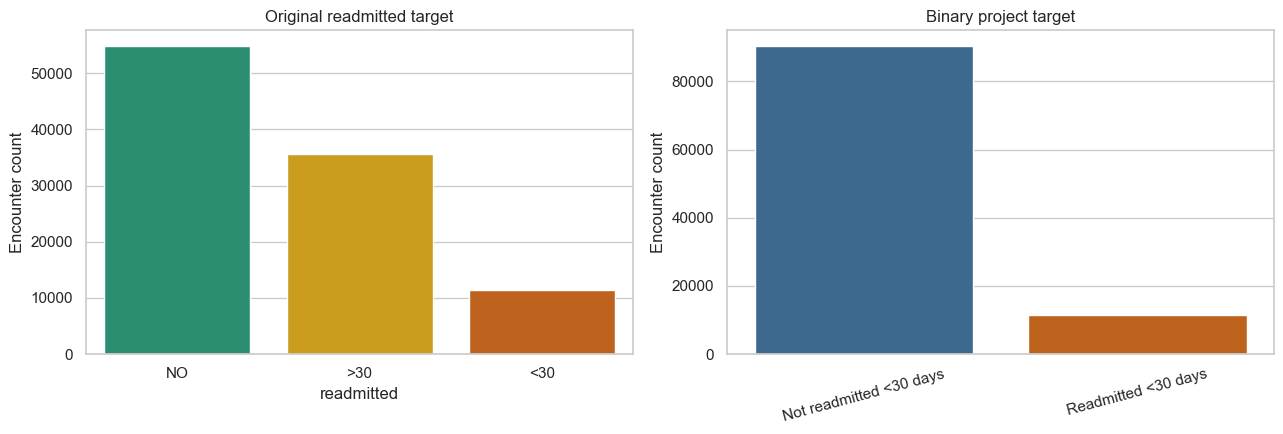

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"], palette=[COLOR_GOOD, COLOR_WARN, COLOR_ACCENT], ax=axes[0])
axes[0].set_title("Original readmitted target")
axes[0].set_xlabel("readmitted")
axes[0].set_ylabel("Encounter count")

sns.countplot(data=df, x="readmitted_30_label", order=["Not readmitted <30 days", "Readmitted <30 days"], palette=[COLOR_MAIN, COLOR_ACCENT], ax=axes[1])
axes[1].set_title("Binary project target")
axes[1].set_xlabel("")
axes[1].set_ylabel("Encounter count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Basic Structure and Data Quality

This section checks shape, data types, cardinality, missingness, duplicates, and columns that may not be useful for modeling.

In [8]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=False),
})
profile = profile.sort_values(["missing_pct", "unique_values"], ascending=[False, False])
display(profile)

,dtype,non_null,missing,missing_pct,unique_values
weight,object,3197,98569,96.858,10
medical_specialty,object,51817,49949,49.082,73
payer_code,object,61510,40256,39.557,18
race,object,99493,2273,2.234,6
diag_3,object,100343,1423,1.398,790
diag_2,object,101408,358,0.352,749
diag_1,object,101745,21,0.021,717
encounter_id,int64,101766,0,0.000,101766
patient_nbr,int64,101766,0,0.000,71518
num_lab_procedures,int64,101766,0,0.000,118


,missing,missing_pct,unique_values
weight,98569,96.858,10
medical_specialty,49949,49.082,73
payer_code,40256,39.557,18
race,2273,2.234,6
diag_3,1423,1.398,790
diag_2,358,0.352,749
diag_1,21,0.021,717


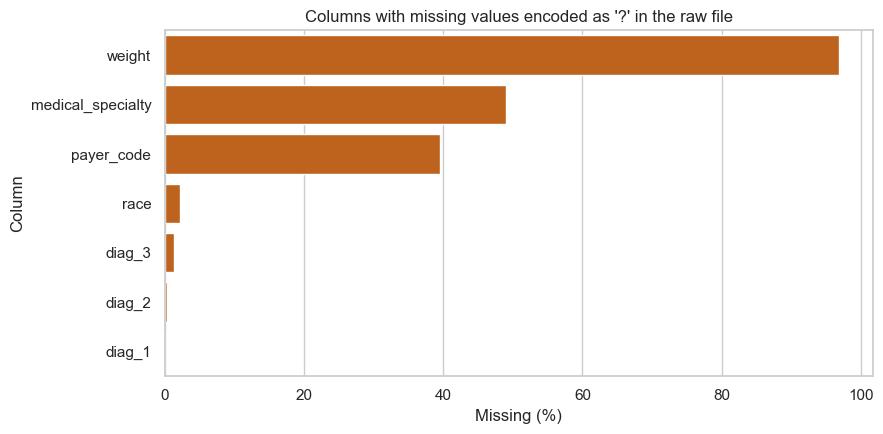

In [9]:
missing = profile[profile["missing"] > 0].copy().sort_values("missing_pct", ascending=False)
display(missing[["missing", "missing_pct", "unique_values"]])

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=missing.reset_index(), x="missing_pct", y="index", color=COLOR_ACCENT, ax=ax)
ax.set_title("Columns with missing values encoded as '?' in the raw file")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

Duplicate encounter_id count: 0
Fully duplicated row count: 0
Unique patients: 71,518
Patients with more than one encounter: 16,773


,encounters_per_patient
count,"71,518.000"
mean,1.423
std,1.091
min,1.000
50%,1.000
75%,1.000
90%,2.000
95%,3.000
99%,6.000
max,40.000


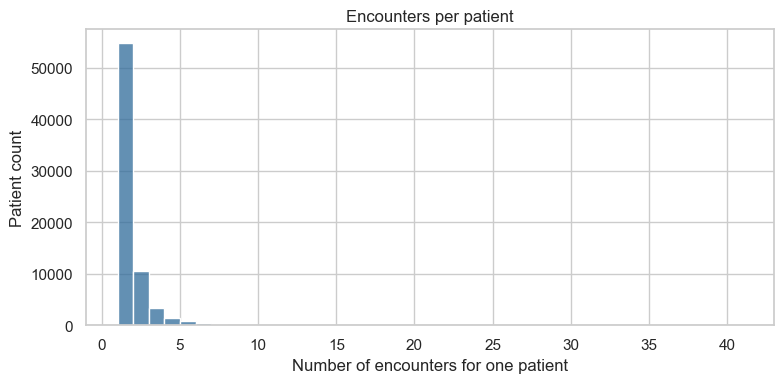

In [10]:
print("Duplicate encounter_id count:", df["encounter_id"].duplicated().sum())
print("Fully duplicated row count:", df.duplicated().sum())
print("Unique patients:", f"{df['patient_nbr'].nunique():,}")
print("Patients with more than one encounter:", f"{(df['patient_nbr'].value_counts() > 1).sum():,}")

patient_encounter_counts = df["patient_nbr"].value_counts()
encounter_summary = patient_encounter_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("encounters_per_patient")
display(encounter_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(patient_encounter_counts, bins=range(1, int(patient_encounter_counts.max()) + 2), color=COLOR_MAIN, ax=ax)
ax.set_title("Encounters per patient")
ax.set_xlabel("Number of encounters for one patient")
ax.set_ylabel("Patient count")
plt.tight_layout()
plt.show()

### Patient/Encounter Granularity Decision

The raw file has multiple encounters for some patients. For modeling, this creates two risks:

1. Train/test leakage if encounters from the same patient appear in both splits.
2. Statistical dependence between rows if the model treats every encounter as independent.

The original clinical study kept only one encounter per patient and excluded discharge-to-hospice/death outcomes. For the next modeling phase, we should compare two defensible strategies:

- **Patient-level split:** keep encounters, but split by `patient_nbr` using a grouped split.
- **First-encounter scope:** keep the first encounter per patient and remove hospice/expired discharges.

This notebook creates the first-encounter scope for EDA comparison but does not force the final modeling choice yet.

In [11]:
HOSPICE_OR_EXPIRED_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

first_encounter_df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first").copy()
model_scope_df = first_encounter_df[~first_encounter_df["discharge_disposition_id"].isin(HOSPICE_OR_EXPIRED_DISCHARGE_IDS)].copy()

scope_summary = pd.DataFrame([
    ("All encounters", len(df), df["patient_nbr"].nunique(), df["readmitted_30"].mean() * 100),
    ("First encounter per patient", len(first_encounter_df), first_encounter_df["patient_nbr"].nunique(), first_encounter_df["readmitted_30"].mean() * 100),
    ("First encounter, excluding hospice/expired", len(model_scope_df), model_scope_df["patient_nbr"].nunique(), model_scope_df["readmitted_30"].mean() * 100),
], columns=["scope", "rows", "unique_patients", "readmitted_30_pct"])

display(scope_summary)

display(pd.concat({
    "all_encounters": df["readmitted"].value_counts(),
    "first_encounter": first_encounter_df["readmitted"].value_counts(),
    "model_scope": model_scope_df["readmitted"].value_counts(),
}, axis=1).fillna(0).astype(int))

,scope,rows,unique_patients,readmitted_30_pct
0,All encounters,101766,71518,11.160
1,First encounter per patient,71518,71518,8.799
2,"First encounter, excluding hospice/expired",69973,69973,8.971


,all_encounters,first_encounter,model_scope
readmitted,,,
NO,54864,42985,41474
>30,35545,22240,22222
<30,11357,6293,6277


## Interpret ID Codes into Practical Groups

The UCI dataset stores admission type, admission source, and discharge disposition as numeric IDs. For EDA and future modeling, compact grouped labels are easier to interpret and less sparse than raw IDs.

In [12]:
def group_admission_type(x):
    if x in [1, 2]:
        return "Emergency/Urgent"
    if x == 3:
        return "Elective"
    if x == 4:
        return "Newborn"
    if x == 7:
        return "Trauma Center"
    if x in [5, 6, 8]:
        return "Unknown/Not mapped"
    return "Other"


def group_discharge_disposition(x):
    if x == 1:
        return "Home"
    if x == 6:
        return "Home health"
    if x == 7:
        return "Left AMA"
    if x in [11, 19, 20, 21]:
        return "Expired"
    if x in [13, 14]:
        return "Hospice"
    if x in [2, 3, 4, 5, 22, 23, 24, 27, 28, 29, 30]:
        return "Transfer/Facility"
    if x in [18, 25, 26]:
        return "Unknown/Not mapped"
    return "Other"


def group_admission_source(x):
    if x in [1, 2, 3]:
        return "Referral"
    if x == 7:
        return "Emergency Room"
    if x in [4, 5, 6, 10, 18, 22, 25, 26]:
        return "Transfer"
    if x in [11, 12, 13, 14, 23, 24]:
        return "Birth-related"
    if x in [9, 15, 17, 20, 21]:
        return "Unknown/Not mapped"
    if x == 8:
        return "Court/Law enforcement"
    return "Other"

for frame in [df, first_encounter_df, model_scope_df]:
    frame["admission_type_group"] = frame["admission_type_id"].apply(group_admission_type)
    frame["discharge_disposition_group"] = frame["discharge_disposition_id"].apply(group_discharge_disposition)
    frame["admission_source_group"] = frame["admission_source_id"].apply(group_admission_source)

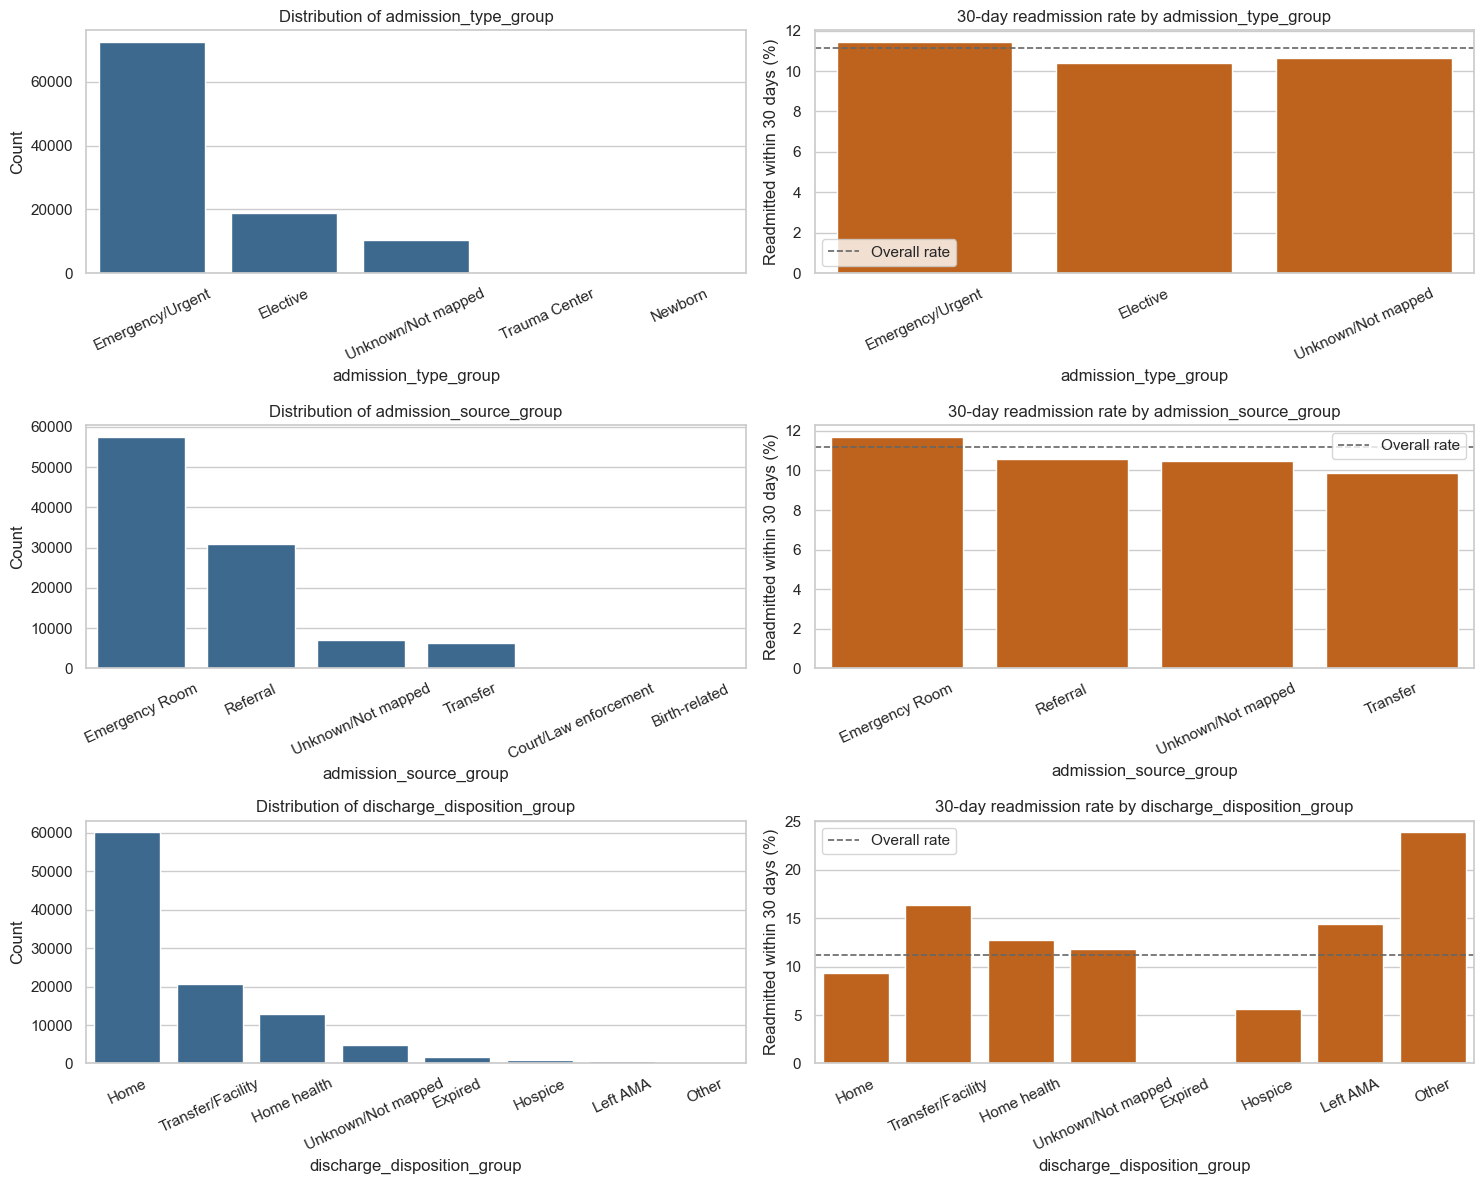

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, col in enumerate(["admission_type_group", "admission_source_group", "discharge_disposition_group"]):
    plot_countplot(df, col, ax=axes[row, 0], rotation=25)
    plot_target_rate(df, col, ax=axes[row, 1], min_count=100, rotation=25)
plt.tight_layout()
plt.show()

## Numeric Feature Distributions

These variables describe the intensity of care during the encounter and recent healthcare utilization before admission.

In [14]:
NUMERIC_COLS = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

display(df[NUMERIC_COLS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
time_in_hospital,"101,766.000",4.396,2.985,1.000,1.000,1.000,2.000,4.000,6.000,11.000,14.000,14.000
num_lab_procedures,"101,766.000",43.096,19.674,1.000,1.000,4.000,31.000,44.000,57.000,73.000,85.000,132.000
num_procedures,"101,766.000",1.340,1.706,0.000,0.000,0.000,0.000,1.000,2.000,5.000,6.000,6.000
num_medications,"101,766.000",16.022,8.128,1.000,3.000,6.000,10.000,15.000,20.000,31.000,43.000,81.000
number_outpatient,"101,766.000",0.369,1.267,0.000,0.000,0.000,0.000,0.000,0.000,2.000,5.000,42.000
number_emergency,"101,766.000",0.198,0.930,0.000,0.000,0.000,0.000,0.000,0.000,1.000,3.000,76.000
number_inpatient,"101,766.000",0.636,1.263,0.000,0.000,0.000,0.000,0.000,1.000,3.000,6.000,21.000
number_diagnoses,"101,766.000",7.423,1.934,1.000,2.000,4.000,6.000,8.000,9.000,9.000,9.000,16.000


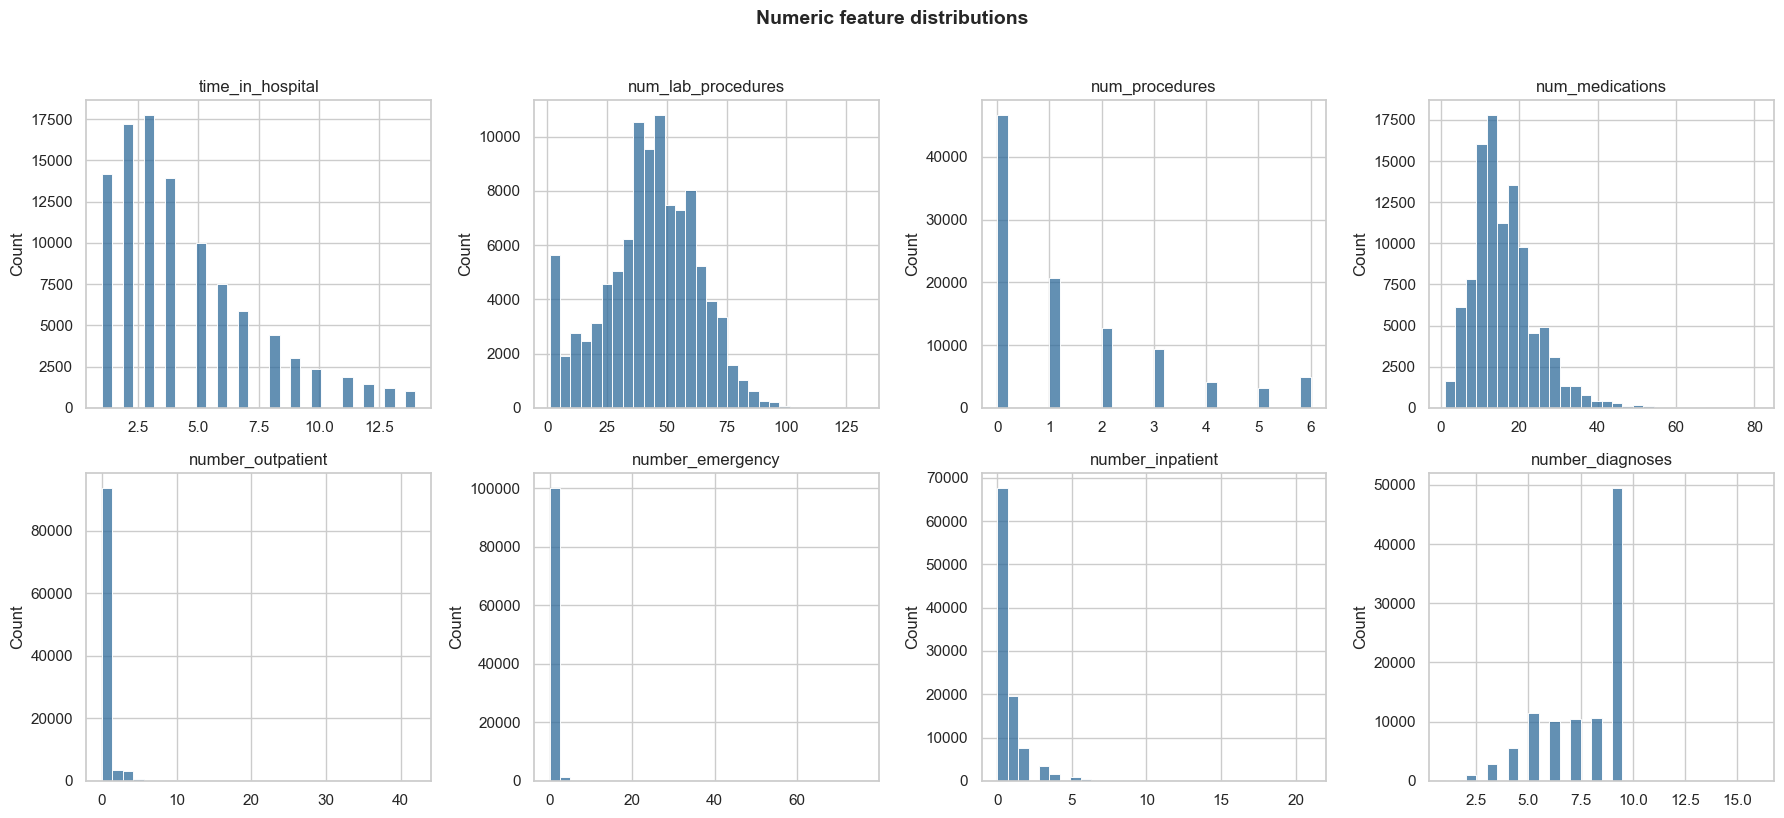

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC_COLS):
    sns.histplot(df[col], bins=30, kde=False, color=COLOR_MAIN, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Numeric feature distributions", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

readmitted_30_label,Not readmitted <30 days,Readmitted <30 days,difference_yes_minus_no
num_lab_procedures,42.954,44.226,1.272
num_medications,15.911,16.903,0.992
number_inpatient,0.562,1.224,0.662
time_in_hospital,4.349,4.768,0.419
number_diagnoses,7.389,7.693,0.304
number_emergency,0.178,0.357,0.180
number_outpatient,0.361,0.437,0.076
num_procedures,1.347,1.281,-0.066


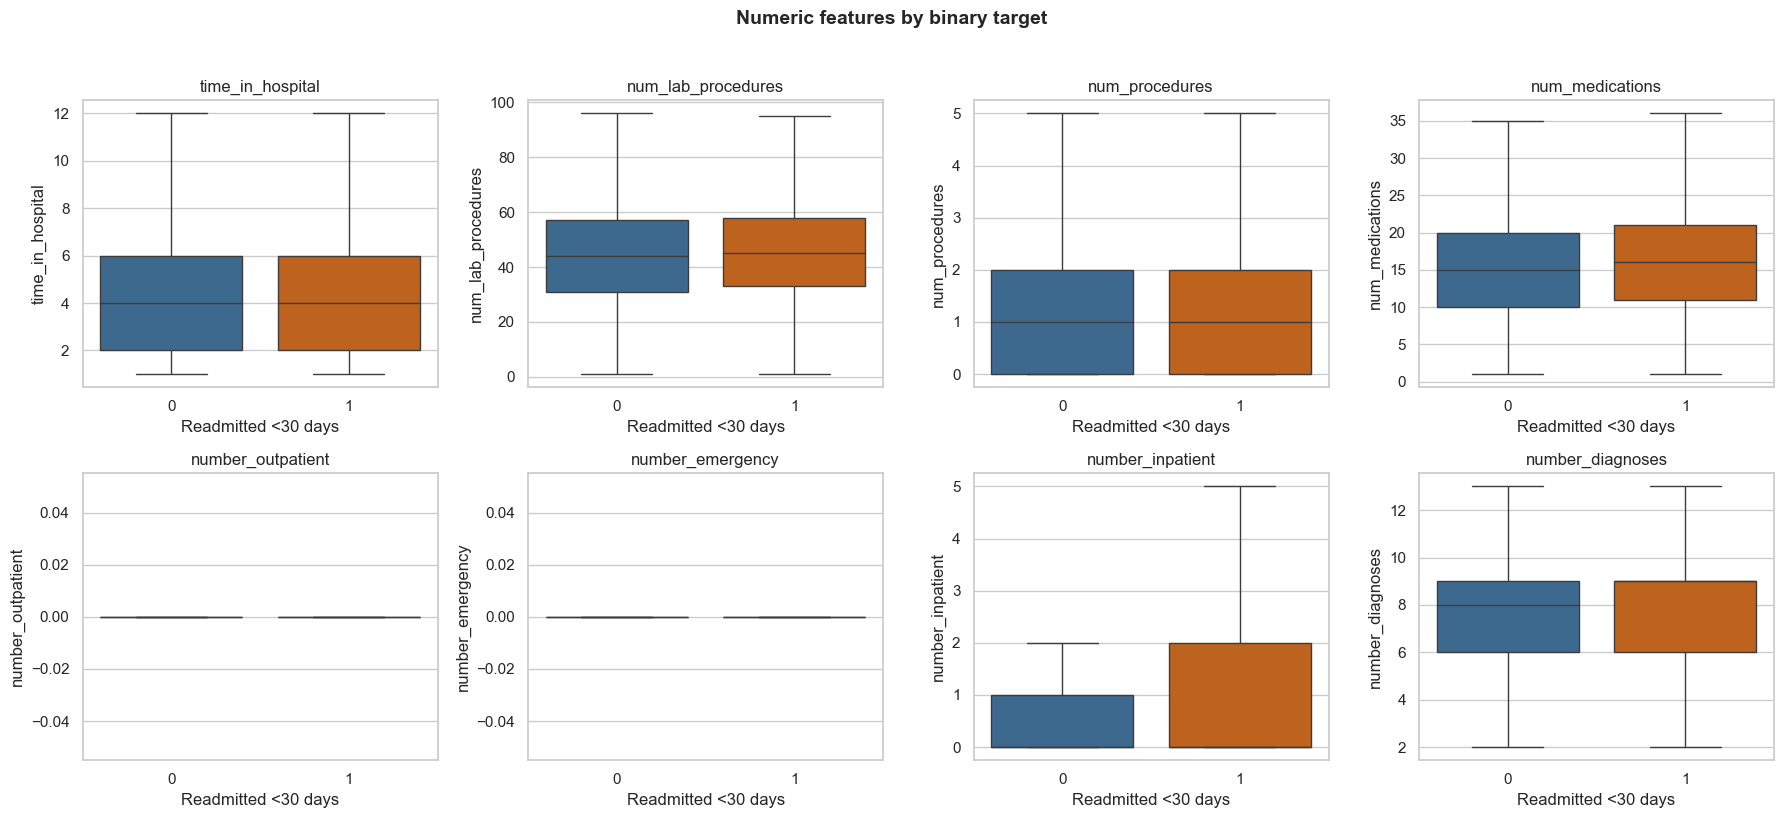

In [16]:
mean_by_target = df.groupby("readmitted_30_label")[NUMERIC_COLS].mean().T
mean_by_target["difference_yes_minus_no"] = mean_by_target["Readmitted <30 days"] - mean_by_target["Not readmitted <30 days"]
display(mean_by_target.sort_values("difference_yes_minus_no", ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(data=df, x="readmitted_30", y=col, palette=[COLOR_MAIN, COLOR_ACCENT], showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Readmitted <30 days")
plt.suptitle("Numeric features by binary target", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Demographic EDA

Age is provided as ordered buckets rather than exact ages. Race has a small amount of missingness. Gender includes a very small `Unknown/Invalid` group.

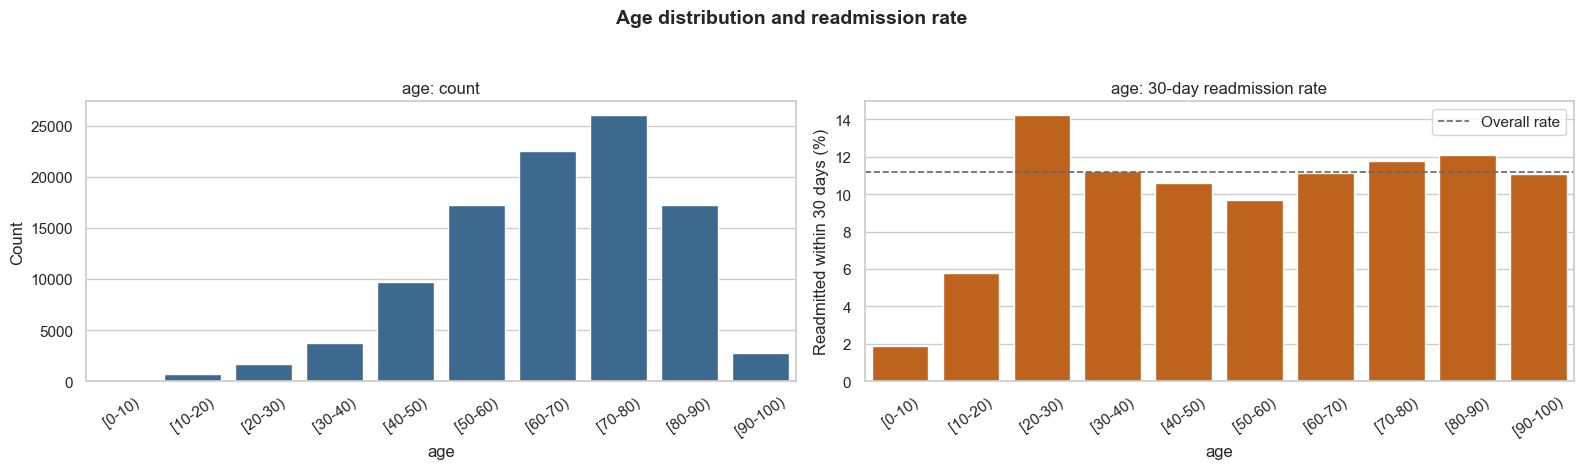

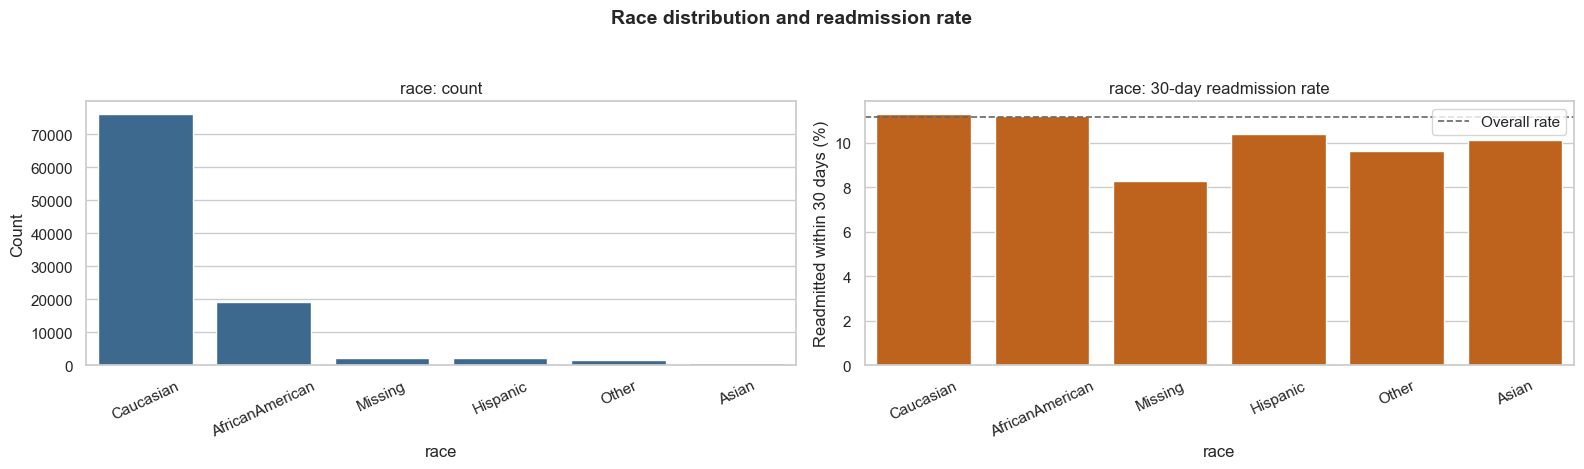

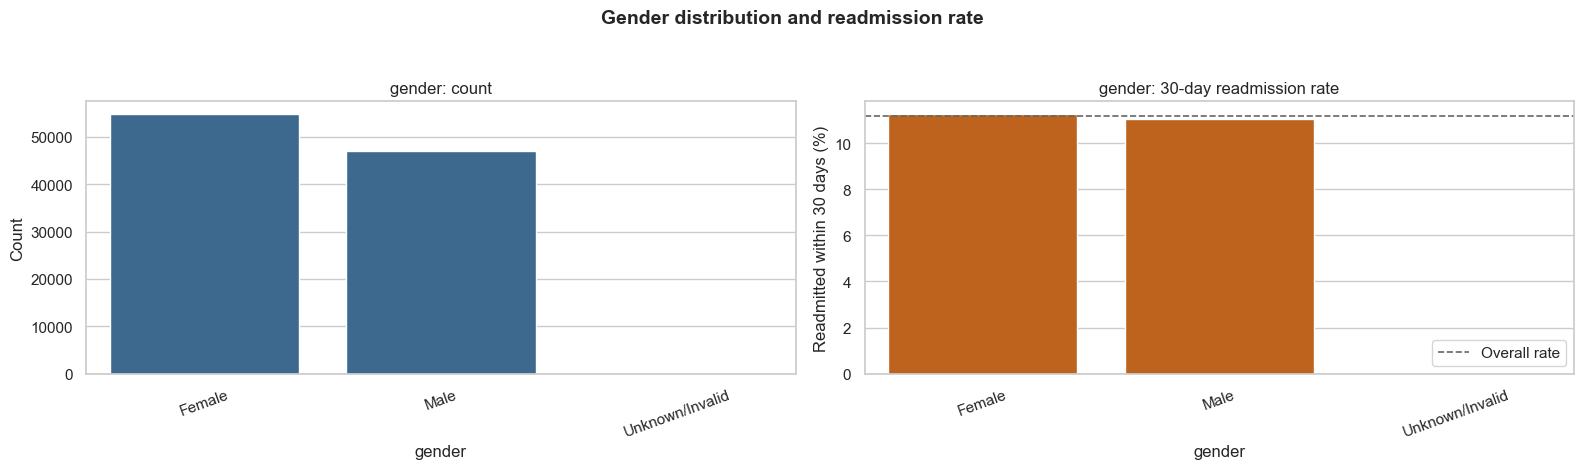

In [17]:
AGE_ORDER = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)", "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]

two_panel_category(df, "age", order=AGE_ORDER, title="Age distribution and readmission rate", rotation=35)
two_panel_category(df, "race", title="Race distribution and readmission rate", rotation=25)
two_panel_category(df, "gender", title="Gender distribution and readmission rate", rotation=20)

## Lab Test EDA

`None` means the test was not performed. The absence of a test can itself be predictive because it reflects clinical workflow and patient severity, so we keep it as a category during EDA.


A1Cresult


,count,percent
A1Cresult,,
None,84748,83.277
>8,8216,8.073
Norm,4990,4.903
>7,3812,3.746


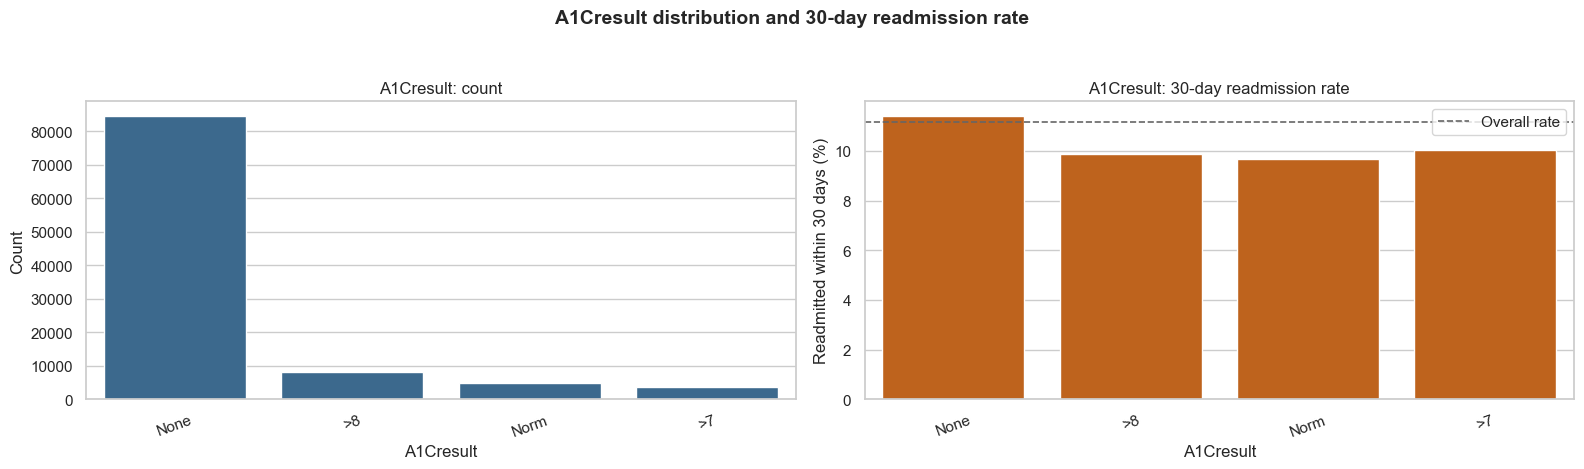


max_glu_serum


,count,percent
max_glu_serum,,
None,96420,94.747
Norm,2597,2.552
>200,1485,1.459
>300,1264,1.242


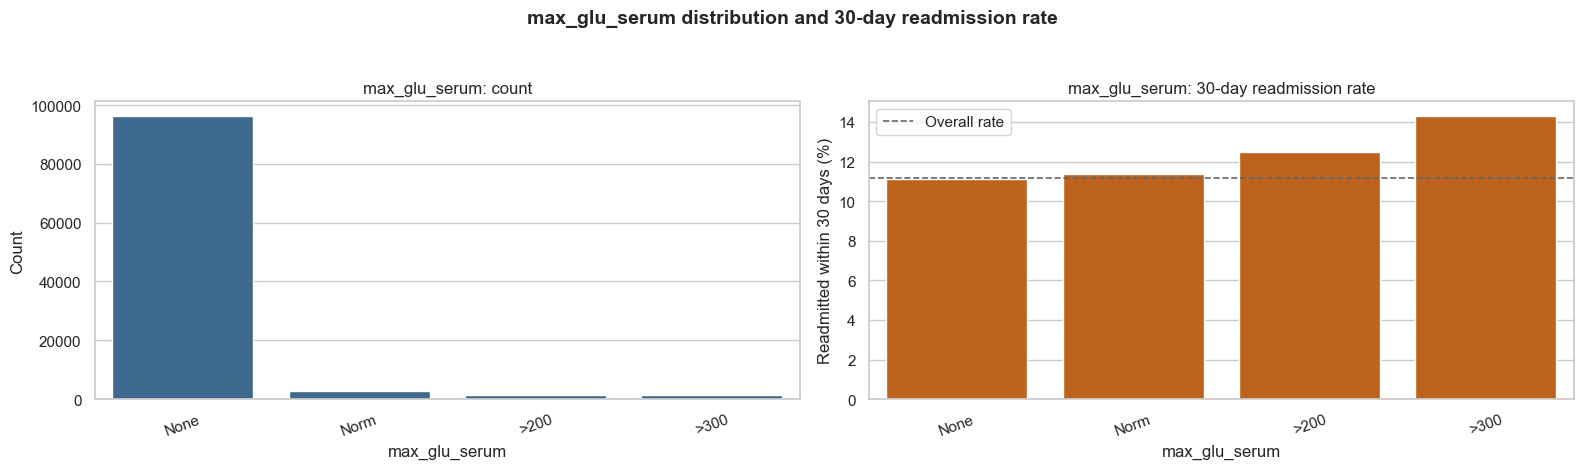

In [18]:
for col in ["A1Cresult", "max_glu_serum"]:
    display_section(col)
    display(count_percent(df[col]))
    two_panel_category(df, col, title=f"{col} distribution and 30-day readmission rate", rotation=20)

## Prior Utilization EDA

Prior inpatient, emergency, and outpatient visits are especially relevant for readmission prediction. They summarize recent healthcare utilization and can act as proxies for illness burden, access issues, and chronic disease instability.

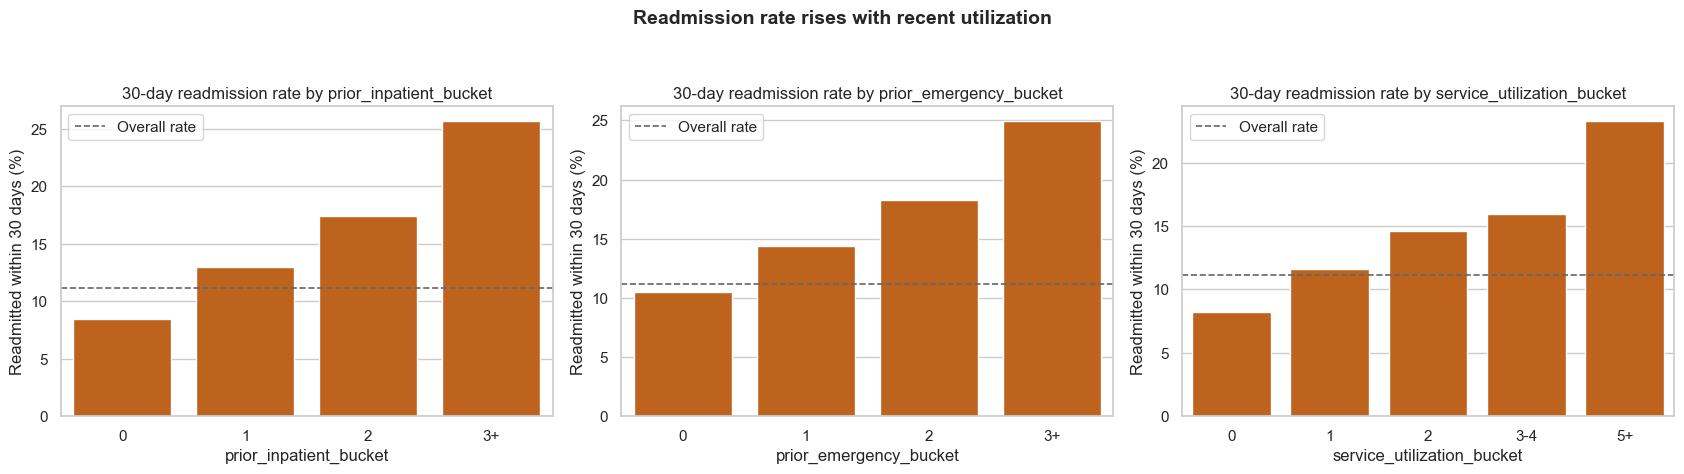

In [19]:
df["service_utilization"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
first_encounter_df["service_utilization"] = first_encounter_df["number_outpatient"] + first_encounter_df["number_emergency"] + first_encounter_df["number_inpatient"]
model_scope_df["service_utilization"] = model_scope_df["number_outpatient"] + model_scope_df["number_emergency"] + model_scope_df["number_inpatient"]

df["prior_inpatient_bucket"] = pd.cut(df["number_inpatient"], bins=[-1, 0, 1, 2, 999], labels=["0", "1", "2", "3+"])
df["prior_emergency_bucket"] = pd.cut(df["number_emergency"], bins=[-1, 0, 1, 2, 999], labels=["0", "1", "2", "3+"])
df["service_utilization_bucket"] = pd.cut(df["service_utilization"], bins=[-1, 0, 1, 2, 4, 999], labels=["0", "1", "2", "3-4", "5+"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
plot_target_rate(df, "prior_inpatient_bucket", order=["0", "1", "2", "3+"], ax=axes[0], rotation=0)
plot_target_rate(df, "prior_emergency_bucket", order=["0", "1", "2", "3+"], ax=axes[1], rotation=0)
plot_target_rate(df, "service_utilization_bucket", order=["0", "1", "2", "3-4", "5+"], ax=axes[2], rotation=0)
plt.suptitle("Readmission rate rises with recent utilization", y=1.05, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Diagnosis EDA

The raw diagnosis columns contain hundreds of ICD-9 codes. For EDA, grouping them into clinical categories makes patterns easier to interpret and produces features that are more useful for modeling.

In [20]:
def icd9_group(code):
    if pd.isna(code):
        return "Missing"
    text = str(code).strip()
    if text == "":
        return "Missing"
    if text.startswith("V") or text.startswith("E"):
        return "External/Supplemental"
    try:
        value = float(text)
    except ValueError:
        return "Other/Unknown"

    whole = int(value)
    if 390 <= value <= 459 or whole == 785:
        return "Circulatory"
    if 460 <= value <= 519 or whole == 786:
        return "Respiratory"
    if 520 <= value <= 579 or whole == 787:
        return "Digestive"
    if 250 <= value < 251:
        return "Diabetes"
    if 800 <= value <= 999:
        return "Injury/Poisoning"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 580 <= value <= 629 or whole == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"

for frame in [df, first_encounter_df, model_scope_df]:
    for diag_col in ["diag_1", "diag_2", "diag_3"]:
        frame[f"{diag_col}_group"] = frame[diag_col].apply(icd9_group)

for diag_group_col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    display_section(diag_group_col)
    display(category_summary(df, diag_group_col).sort_values("count", ascending=False))


diag_1_group


,category,count,readmit_rate,readmit_rate_pct
0,Circulatory,30437,0.114,11.450
9,Other,16527,0.110,11.012
10,Respiratory,14423,0.097,9.728
2,Digestive,9475,0.107,10.712
1,Diabetes,8757,0.130,12.984
5,Injury/Poisoning,6974,0.122,12.245
4,Genitourinary,5117,0.108,10.846
7,Musculoskeletal,4957,0.095,9.502
8,Neoplasms,3433,0.101,10.079
3,External/Supplemental,1645,0.162,16.170



diag_2_group


,category,count,readmit_rate,readmit_rate_pct
0,Circulatory,31881,0.111,11.101
9,Other,24017,0.113,11.280
1,Diabetes,12794,0.106,10.583
10,Respiratory,10895,0.105,10.519
4,Genitourinary,8376,0.118,11.760
2,Digestive,4170,0.115,11.487
8,Neoplasms,2547,0.149,14.920
3,External/Supplemental,2536,0.111,11.080
5,Injury/Poisoning,2428,0.114,11.450
7,Musculoskeletal,1764,0.100,10.034



diag_3_group


,category,count,readmit_rate,readmit_rate_pct
0,Circulatory,30306,0.108,10.806
9,Other,24137,0.112,11.223
1,Diabetes,17157,0.106,10.567
10,Respiratory,7358,0.121,12.055
4,Genitourinary,6680,0.135,13.458
3,External/Supplemental,5058,0.103,10.281
2,Digestive,3930,0.120,11.959
5,Injury/Poisoning,1946,0.116,11.562
7,Musculoskeletal,1915,0.107,10.653
8,Neoplasms,1856,0.142,14.224


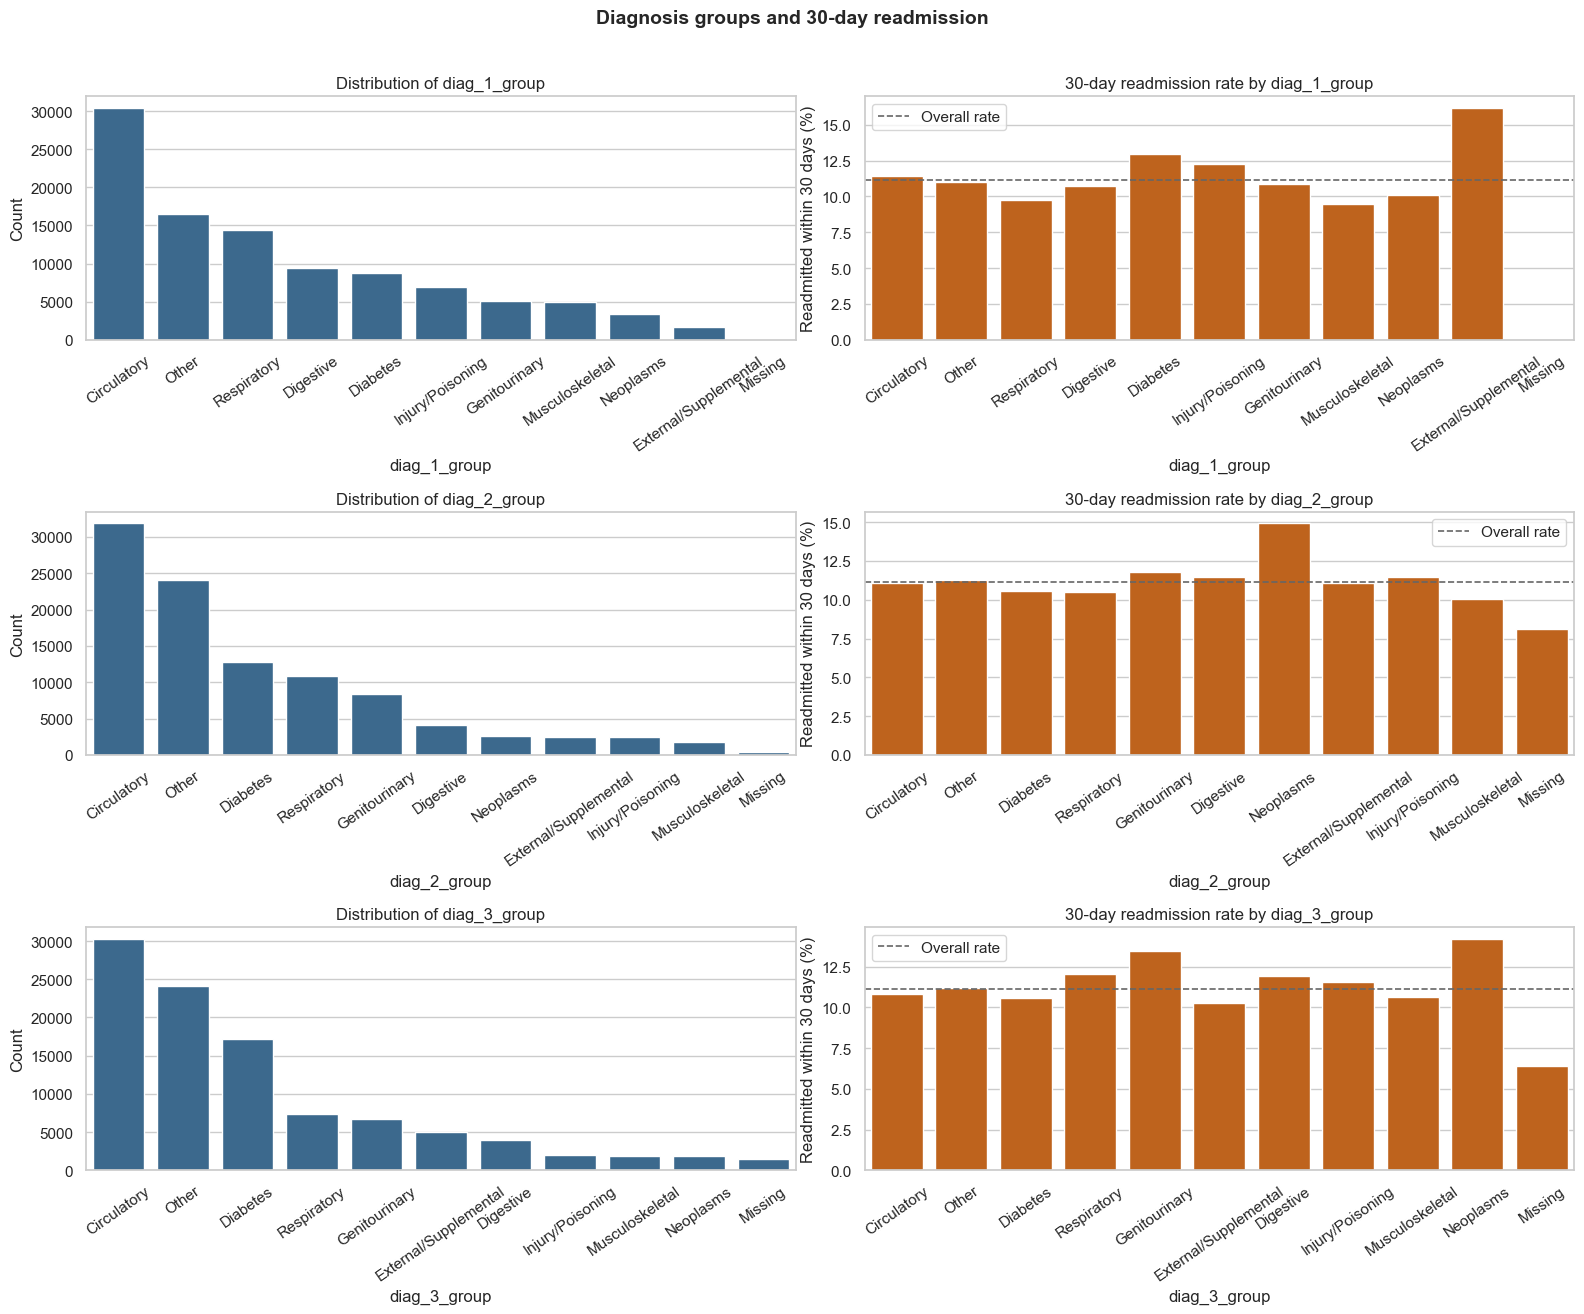

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
for row, col in enumerate(["diag_1_group", "diag_2_group", "diag_3_group"]):
    order = df[col].value_counts().index
    plot_countplot(df, col, order=order, ax=axes[row, 0], rotation=35)
    plot_target_rate(df, col, order=order, ax=axes[row, 1], min_count=100, rotation=35)
plt.suptitle("Diagnosis groups and 30-day readmission", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Medication EDA

The medication columns indicate whether each diabetes medication was not prescribed, prescribed steadily, increased, or decreased during the encounter. We summarize them into interpretable counts while keeping the original columns available for modeling.

In [22]:
MEDICATION_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]

for frame in [df, first_encounter_df, model_scope_df]:
    frame["num_diabetes_meds_used"] = frame[MEDICATION_COLS].ne("No").sum(axis=1)
    frame["num_diabetes_med_changes"] = frame[MEDICATION_COLS].isin(["Up", "Down"]).sum(axis=1)
    frame["any_medication_changed"] = frame["change"].eq("Ch").astype(int)

med_summary = []
for col in MEDICATION_COLS:
    med_summary.append({
        "medication": col,
        "used_count": int(df[col].ne("No").sum()),
        "used_pct": df[col].ne("No").mean() * 100,
        "changed_count": int(df[col].isin(["Up", "Down"]).sum()),
        "changed_pct": df[col].isin(["Up", "Down"]).mean() * 100,
        "unique_values": ", ".join(map(str, sorted(df[col].dropna().unique()))),
    })
med_summary = pd.DataFrame(med_summary).sort_values("used_count", ascending=False)
display(med_summary)

,medication,used_count,used_pct,changed_count,changed_pct,unique_values
17,insulin,54383,53.439,23534,23.126,"Down, No, Steady, Up"
0,metformin,19988,19.641,1642,1.614,"Down, No, Steady, Up"
6,glipizide,12686,12.466,1330,1.307,"Down, No, Steady, Up"
7,glyburide,10650,10.465,1376,1.352,"Down, No, Steady, Up"
9,pioglitazone,7328,7.201,352,0.346,"Down, No, Steady, Up"
10,rosiglitazone,6365,6.255,265,0.260,"Down, No, Steady, Up"
4,glimepiride,5191,5.101,521,0.512,"Down, No, Steady, Up"
1,repaglinide,1539,1.512,155,0.152,"Down, No, Steady, Up"
18,glyburide-metformin,706,0.694,14,0.014,"Down, No, Steady, Up"
2,nateglinide,703,0.691,35,0.034,"Down, No, Steady, Up"


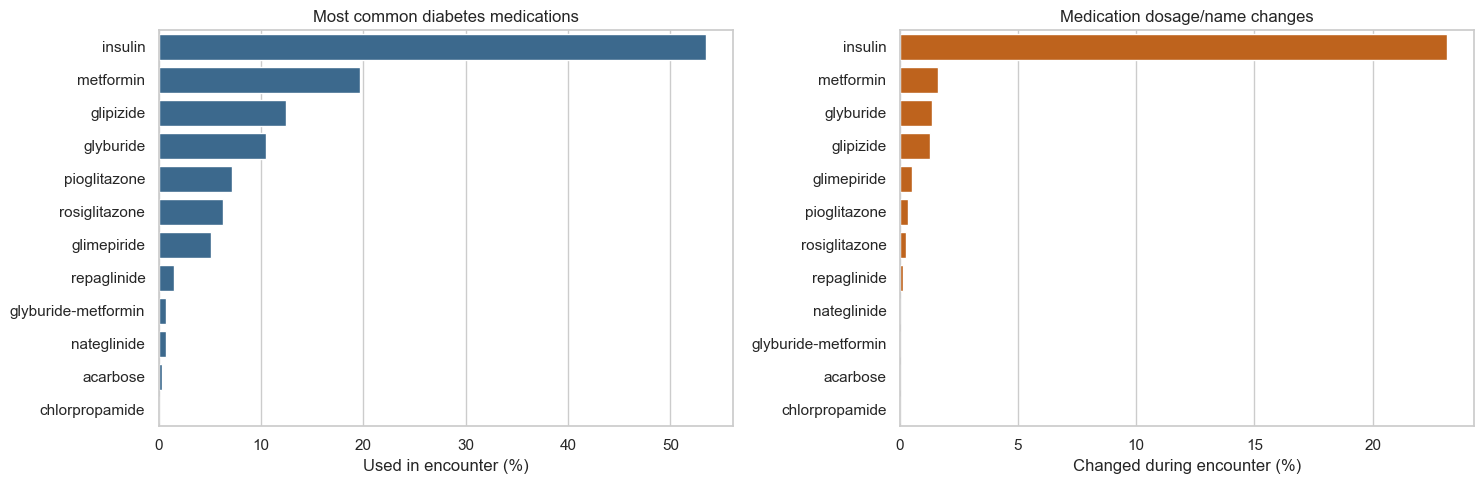

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = med_summary.head(12)
sns.barplot(data=plot_df, x="used_pct", y="medication", color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Most common diabetes medications")
axes[0].set_xlabel("Used in encounter (%)")
axes[0].set_ylabel("")

sns.barplot(data=plot_df.sort_values("changed_pct", ascending=False), x="changed_pct", y="medication", color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("Medication dosage/name changes")
axes[1].set_xlabel("Changed during encounter (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

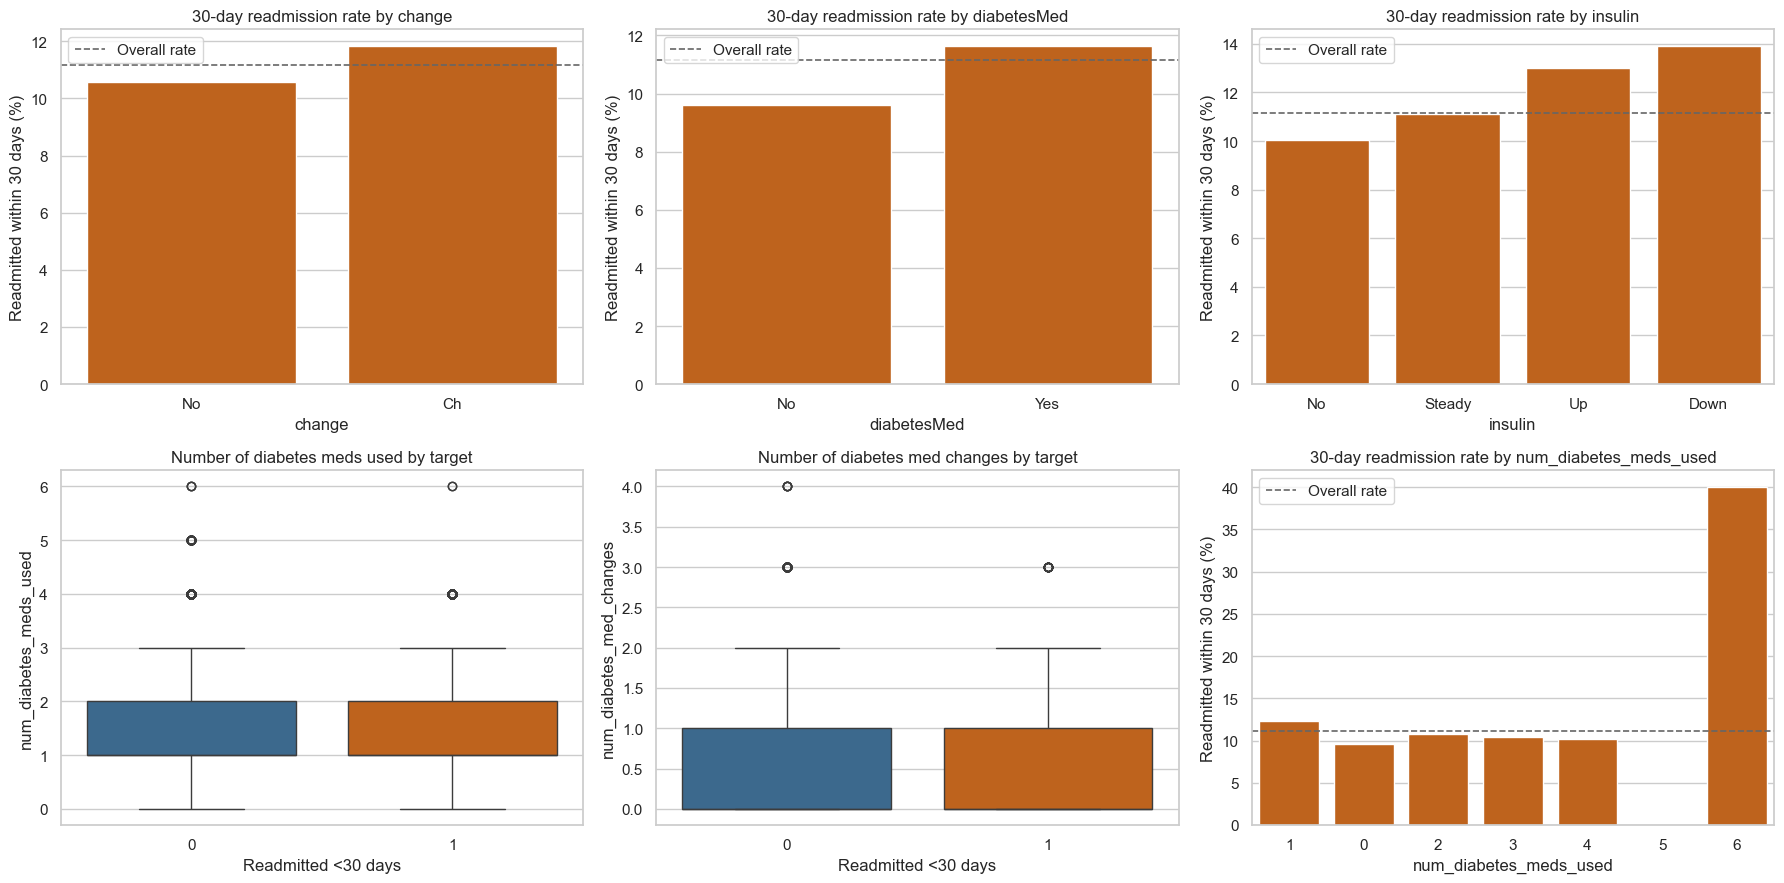

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
plot_target_rate(df, "change", order=["No", "Ch"], ax=axes[0, 0], rotation=0)
plot_target_rate(df, "diabetesMed", order=["No", "Yes"], ax=axes[0, 1], rotation=0)
plot_target_rate(df, "insulin", order=["No", "Steady", "Up", "Down"], ax=axes[0, 2], rotation=0)

sns.boxplot(data=df, x="readmitted_30", y="num_diabetes_meds_used", palette=[COLOR_MAIN, COLOR_ACCENT], ax=axes[1, 0])
axes[1, 0].set_title("Number of diabetes meds used by target")
axes[1, 0].set_xlabel("Readmitted <30 days")

sns.boxplot(data=df, x="readmitted_30", y="num_diabetes_med_changes", palette=[COLOR_MAIN, COLOR_ACCENT], ax=axes[1, 1])
axes[1, 1].set_title("Number of diabetes med changes by target")
axes[1, 1].set_xlabel("Readmitted <30 days")

plot_target_rate(df, "num_diabetes_meds_used", ax=axes[1, 2], rotation=0)
plt.tight_layout()
plt.show()

## High-Cardinality Administrative Features

`medical_specialty` and `payer_code` have many categories and substantial missingness. For modeling, they should likely be grouped into top categories plus `Other`/`Missing`, or handled with encoders that can manage rare categories.


medical_specialty


,count,percent
medical_specialty,,
NaN,49949,49.082
InternalMedicine,14635,14.381
Emergency/Trauma,7565,7.434
Family/GeneralPractice,7440,7.311
Cardiology,5352,5.259
Surgery-General,3099,3.045
Nephrology,1613,1.585
Orthopedics,1400,1.376
Orthopedics-Reconstructive,1233,1.212


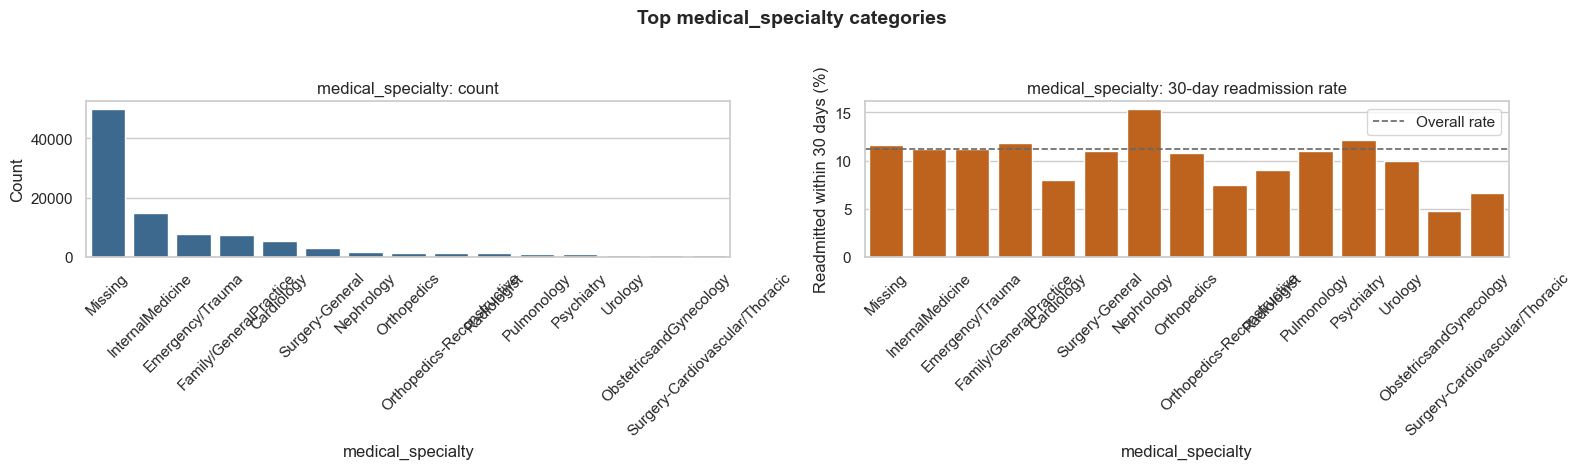


payer_code


,count,percent
payer_code,,
NaN,40256,39.557
MC,32439,31.876
HM,6274,6.165
SP,5007,4.920
BC,4655,4.574
MD,3532,3.471
CP,2533,2.489
UN,2448,2.406
CM,1937,1.903


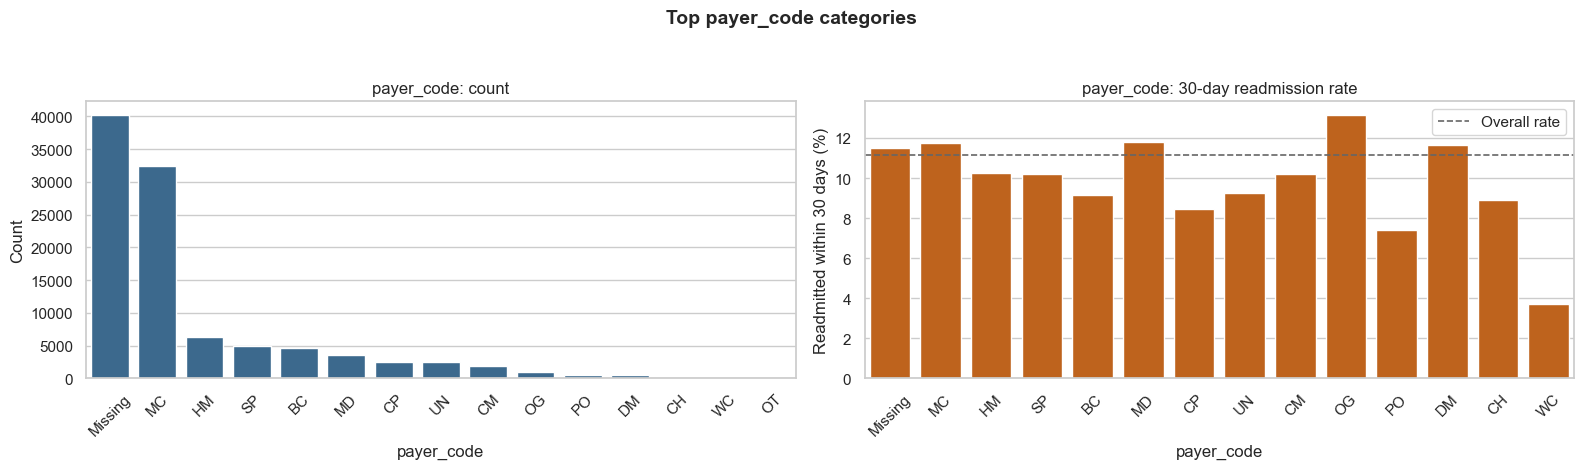

In [25]:
for col in ["medical_specialty", "payer_code"]:
    display_section(col)
    display(count_percent(df[col]).head(20))
    two_panel_category(df, col, top_n=15, min_count=100, title=f"Top {col} categories", rotation=45)

## Correlation View for Numeric and Engineered Counts

Correlation does not prove causation, but it helps identify redundant variables and early signals. Because the target is binary, the target correlations below are rough linear associations only.

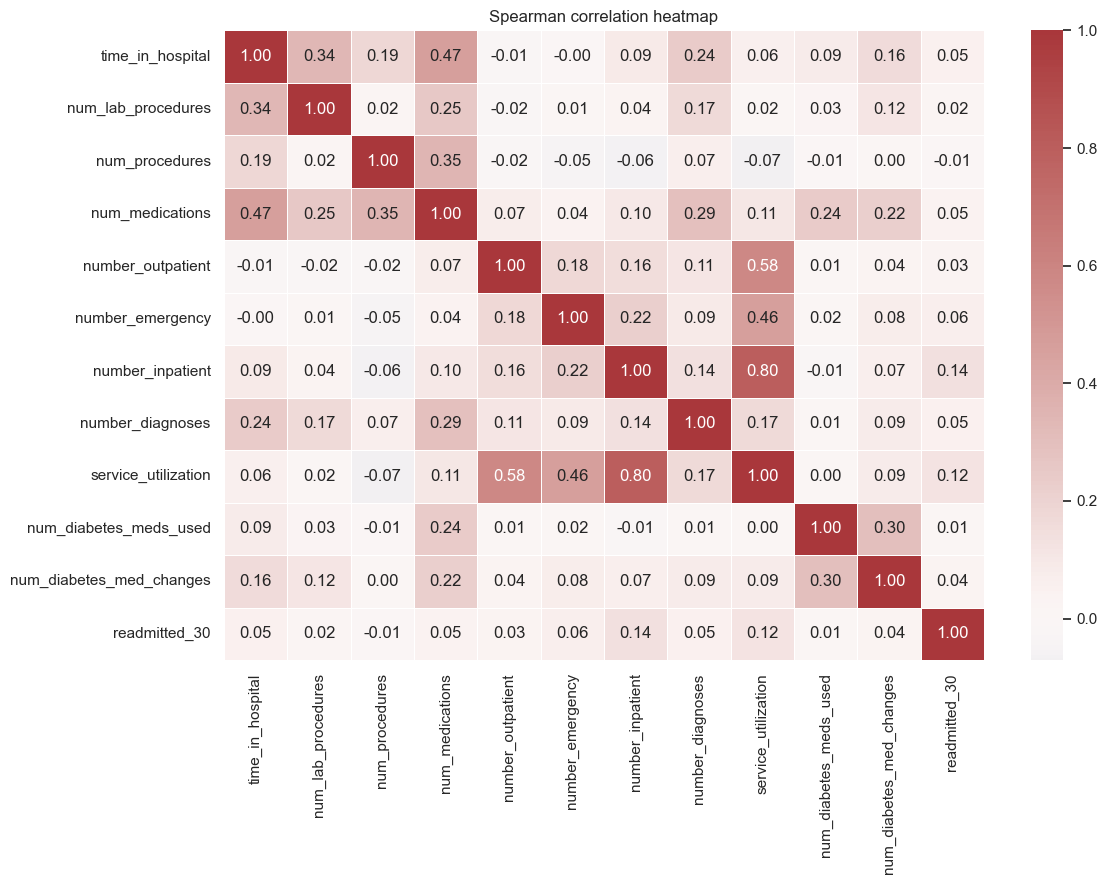

,spearman_corr_with_target
number_inpatient,0.138
service_utilization,0.124
number_emergency,0.063
time_in_hospital,0.051
number_diagnoses,0.047
num_medications,0.045
num_diabetes_med_changes,0.037
number_outpatient,0.034
num_lab_procedures,0.021
num_diabetes_meds_used,0.007


In [26]:
CORR_COLS = NUMERIC_COLS + [
    "service_utilization",
    "num_diabetes_meds_used",
    "num_diabetes_med_changes",
    "readmitted_30",
]

corr = df[CORR_COLS].corr(method="spearman")
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()

target_corr = corr["readmitted_30"].drop("readmitted_30").sort_values(key=lambda s: s.abs(), ascending=False).to_frame("spearman_corr_with_target")
display(target_corr)

## Outlier and Skew Checks

Recent utilization variables are highly skewed: most patients have zero prior visits, while a small number have very high counts. In modeling, tree-based models can handle this reasonably well, but linear models may benefit from capping, log transforms, or bucketed features.

,count,mean,std,min,50%,75%,90%,95%,99%,max,skew
number_outpatient,"101,766.000",0.369,1.267,0.000,0.000,0.000,1.000,2.000,5.000,42.000,8.833
number_emergency,"101,766.000",0.198,0.930,0.000,0.000,0.000,1.000,1.000,3.000,76.000,22.856
number_inpatient,"101,766.000",0.636,1.263,0.000,0.000,1.000,2.000,3.000,6.000,21.000,3.614
service_utilization,"101,766.000",1.203,2.292,0.000,0.000,2.000,3.000,5.000,10.000,80.000,5.315
num_medications,"101,766.000",16.022,8.128,1.000,15.000,20.000,26.000,31.000,43.000,81.000,1.327
num_lab_procedures,"101,766.000",43.096,19.674,1.000,44.000,57.000,67.000,73.000,85.000,132.000,-0.237


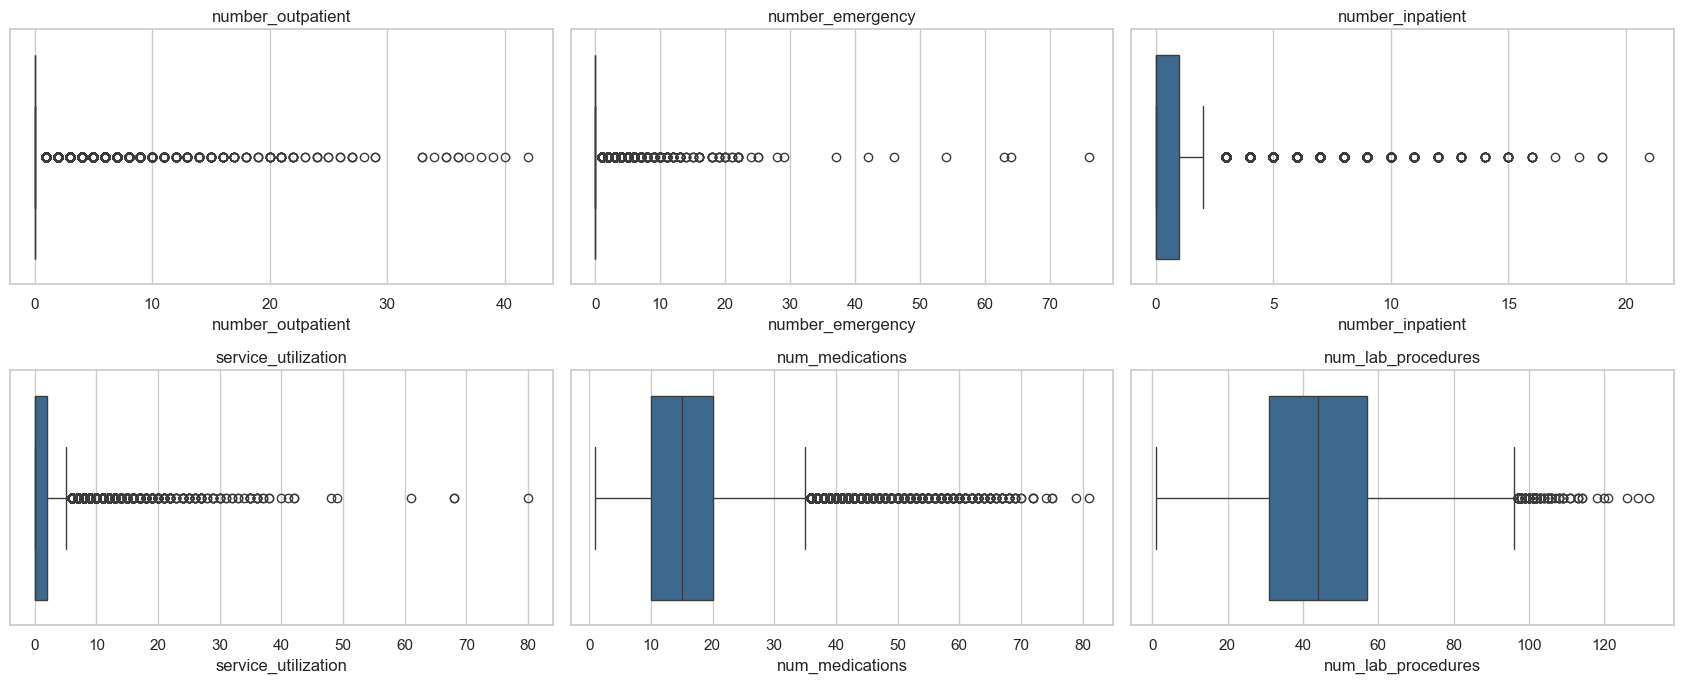

In [27]:
skew_cols = ["number_outpatient", "number_emergency", "number_inpatient", "service_utilization", "num_medications", "num_lab_procedures"]
outlier_summary = df[skew_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
outlier_summary["skew"] = df[skew_cols].skew()
display(outlier_summary)

fig, axes = plt.subplots(2, 3, figsize=(17, 7))
for ax, col in zip(axes.ravel(), skew_cols):
    sns.boxplot(x=df[col], color=COLOR_MAIN, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## EDA Tables for Report

These compact tables are useful for the written report's Problem & Data section: sample count, feature count, class balance, missing values, and high-signal EDA observations.

In [28]:
report_dataset_stats = pd.DataFrame({
    "metric": [
        "Rows / encounters",
        "Columns before engineered EDA features",
        "Unique patients",
        "30-day readmission positive rate",
        "Majority baseline accuracy",
        "Rows after first-encounter alive/non-hospice scope",
        "30-day positive rate after first-encounter alive/non-hospice scope",
    ],
    "value": [
        f"{len(raw):,}",
        f"{raw.shape[1]:,}",
        f"{raw['patient_nbr'].nunique():,}",
        f"{df['readmitted_30'].mean() * 100:.2f}%",
        f"{majority_baseline_accuracy * 100:.2f}%",
        f"{len(model_scope_df):,}",
        f"{model_scope_df['readmitted_30'].mean() * 100:.2f}%",
    ]
})

display(report_dataset_stats)

display(missing[["missing", "missing_pct"]].round(2))

,metric,value
0,Rows / encounters,"101,766"
1,Columns before engineered EDA features,50
2,Unique patients,"71,518"
3,30-day readmission positive rate,11.16%
4,Majority baseline accuracy,88.84%
5,Rows after first-encounter alive/non-hospice s...,"69,973"
6,30-day positive rate after first-encounter ali...,8.97%


,missing,missing_pct
weight,98569,96.860
medical_specialty,49949,49.080
payer_code,40256,39.560
race,2273,2.230
diag_3,1423,1.400
diag_2,358,0.350
diag_1,21,0.020


In [29]:
key_rate_tables = {
    "age": category_summary(df, "age", order=AGE_ORDER),
    "prior_inpatient_bucket": category_summary(df, "prior_inpatient_bucket", order=["0", "1", "2", "3+"]),
    "A1Cresult": category_summary(df, "A1Cresult"),
    "max_glu_serum": category_summary(df, "max_glu_serum"),
    "diag_1_group": category_summary(df, "diag_1_group"),
    "discharge_disposition_group": category_summary(df, "discharge_disposition_group", min_count=100),
}

for name, table in key_rate_tables.items():
    display_section(name)
    display(table[["category", "count", "readmit_rate_pct"]].round(2))


===
age
===


,category,count,readmit_rate_pct
0,[0-10),161,1.860
1,[10-20),691,5.790
2,[20-30),1657,14.240
3,[30-40),3775,11.230
4,[40-50),9685,10.600
5,[50-60),17256,9.670
6,[60-70),22483,11.130
7,[70-80),26068,11.770
8,[80-90),17197,12.080
9,[90-100),2793,11.100



prior_inpatient_bucket


,category,count,readmit_rate_pct
0,0,67630,8.440
1,1,19521,12.920
2,2,7566,17.430
3,3+,7049,25.660



A1Cresult


...

,category,count,readmit_rate_pct
2,None,96420,11.090
3,Norm,2597,11.360
0,>200,1485,12.460
1,>300,1264,14.320



diag_1_group


,category,count,readmit_rate_pct
0,Circulatory,30437,11.450
9,Other,16527,11.010
10,Respiratory,14423,9.730
2,Digestive,9475,10.710
1,Diabetes,8757,12.980
5,Injury/Poisoning,6974,12.250
4,Genitourinary,5117,10.850
7,Musculoskeletal,4957,9.500
8,Neoplasms,3433,10.080
3,External/Supplemental,1645,16.170



discharge_disposition_group


,category,count,readmit_rate_pct
1,Home,60234,9.300
6,Transfer/Facility,20678,16.340
2,Home health,12902,12.700
7,Unknown/Not mapped,4680,11.770
0,Expired,1652,0.000
3,Hospice,771,5.580
4,Left AMA,623,14.450
5,Other,226,23.890


## Modeling-Readiness Notes for the Next Phase

Recommended next decisions:

1. **Target:** Use `readmitted_30 = 1` for `<30`, else `0`.
2. **Rows:** Either use a patient-grouped train/test split across all encounters or use first encounter per patient. The first-encounter alive/non-hospice scope is closest to the original study's analysis design.
3. **Do not use IDs as predictors:** Drop `encounter_id` and usually `patient_nbr` from feature matrices.
4. **Missingness:** Drop `weight` or convert it to a missingness indicator because it is almost entirely missing. Treat `medical_specialty`, `payer_code`, and `race` missingness intentionally.
5. **Categorical features:** Use one-hot encoding with rare-category grouping for high-cardinality columns.
6. **Diagnosis features:** Use grouped ICD-9 categories for `diag_1`, `diag_2`, `diag_3`; optionally keep top raw codes as additional features later.
7. **Medication features:** Keep original medication status columns and add summaries like `num_diabetes_meds_used`, `num_diabetes_med_changes`, and `service_utilization`.
8. **Class imbalance:** The positive class is around 11% in all encounters and around 9% in the first-encounter alive/non-hospice scope. Accuracy alone is not enough; compare recall, precision, F1, ROC-AUC, and especially PR-AUC.
9. **Baseline:** A simple baseline is majority-class prediction or logistic regression with minimal preprocessing. The final models must beat this baseline.
10. **Model candidates:** Logistic Regression, Decision Tree/Random Forest, Gradient Boosting, and possibly XGBoost/LightGBM if allowed by the environment.

## Main EDA Takeaways

- The dataset is suitable for the selected course topic because it has a direct 30-day readmission target
- The target is imbalanced: only a minority of encounters are readmitted within 30 days
- `weight`, `medical_specialty`, and `payer_code` require explicit missing-value decisions
- Multiple encounters per patient must be handled carefully to avoid leakage
- Prior utilization, especially prior inpatient visits, appears strongly associated with 30-day readmission
- Diagnosis groups, discharge disposition, admission source/type, medication changes, and lab-test categories are important EDA dimensions for the modeling phase

The next notebook should focus on preprocessing pipelines, baseline modeling, model comparison, and error analysis.